Пустых значений в начале:
Индекс промышленного производства    0
Trend                                0
Seasonal                             0
Resid                                0
dtype: int64

Пустых значений в конце:
Индекс промышленного производства    0
Trend                                0
Seasonal                             0
Resid                                0
dtype: int64


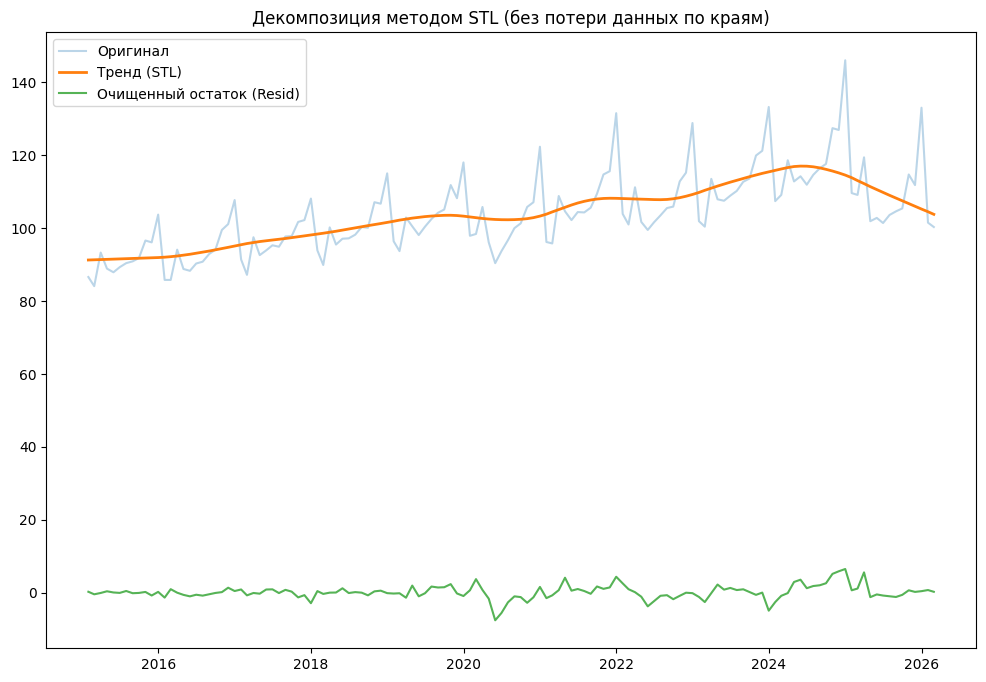

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# 1. Загрузка и подготовка
df = pd.read_excel('индекс_промышленного_производства.xlsx')
df['Дата'] = pd.to_datetime(df['Дата'])
df = df.sort_values('Дата').reset_index(drop=True)
df.set_index('Дата', inplace=True)

# Обязательно задаем частоту (Month Start или Month End), STL это требует
df.index.freq = df.index.inferred_freq 

# 2. STL декомпозиция
# period=12 (годовая сезонность)
# robust=True помогает, если в данных есть резкие аномалии (например, 2020 или 2022 год)
stl = STL(df['Индекс промышленного производства'], period=12, robust=True)
result = stl.fit()

# 3. Сохраняем результаты (здесь НЕ БУДЕТ NaN)
df['Trend'] = result.trend
df['Seasonal'] = result.seasonal
df['Resid'] = result.resid  # Это и есть очищенный ряд (остаток)

# 4. Проверка на пустые значения
print(f"Пустых значений в начале:\n{df.head(3).isna().sum()}")
print(f"\nПустых значений в конце:\n{df.tail(3).isna().sum()}")

# 5. Визуализация
plt.figure(figsize=(12, 8))
plt.plot(df.index, df['Индекс промышленного производства'], label='Оригинал', alpha=0.3)
plt.plot(df.index, df['Trend'], label='Тренд (STL)', linewidth=2)
plt.plot(df.index, df['Resid'], label='Очищенный остаток (Resid)', alpha=0.8)
plt.legend()
plt.title('Декомпозиция методом STL (без потери данных по краям)')
plt.show()

In [18]:
df

,Индекс промышленного производства,Trend,Seasonal,Resid
Дата,,,,
2015-01-31,86.5,91.163441,-4.904607,0.241166
2015-02-28,84.0,91.219407,-6.761812,-0.457596
2015-03-31,93.2,91.275674,2.013661,-0.089335
2015-04-30,88.8,91.332497,-2.904875,0.372377
2015-05-31,87.8,91.390253,-3.635937,0.045685
...,...,...,...,...
2025-10-31,114.6,106.607439,7.348756,0.643805
2025-11-30,111.7,105.861203,5.634972,0.203825
2025-12-31,132.9,105.123869,27.371040,0.405091


In [20]:
df['Date'] = df.index.to_period('M')
df.rename(columns = {'Resid' : 'GDP_promproduction_clean'}, inplace=True)

df[['Date', 'GDP_promproduction_clean']].to_csv('gdp_proxy.csv', index=False)
df[['Date', 'GDP_promproduction_clean']].to_excel('gdp_proxy.xlsx', index=False)

In [3]:
mpu_index.to_csv('RussiaNewsBasedUncertainty.csv', index=False)
mpu_index.to_excel('RussiaNewsBasedUncertainty.xlsx', index=False)

In [2]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
